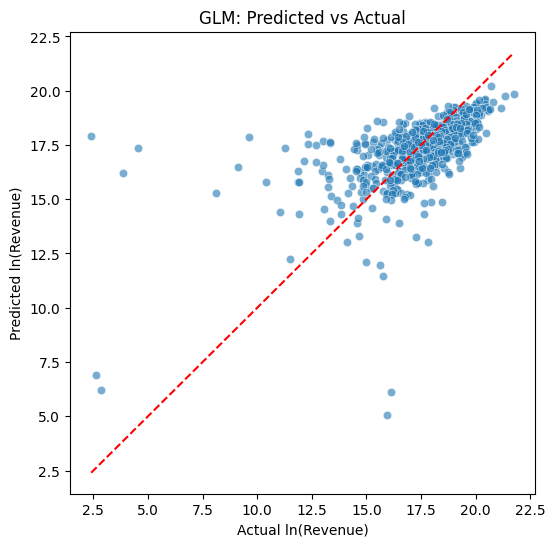

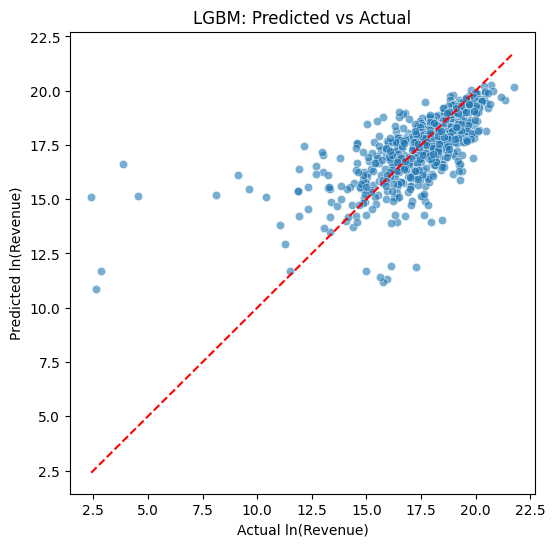

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

from _load_predictions import load_predict_parquet

df = load_predict_parquet()

def plot_pred_vs_actual(df, pred_col, actual_col='ln_revenue', model_name='Model'):
    plt.figure(figsize=(6,6))
    sns.scatterplot(x=df[actual_col], y=df[pred_col], alpha=0.6)
    plt.plot([df[actual_col].min(), df[actual_col].max()],
             [df[actual_col].min(), df[actual_col].max()],
             'r--')
    plt.xlabel("Actual ln(Revenue)")
    plt.ylabel("Predicted ln(Revenue)")
    plt.title(f"{model_name}: Predicted vs Actual")
    plt.show()

plot_pred_vs_actual(df, 'pred_glm', model_name='GLM')
plot_pred_vs_actual(df, 'pred_lgbm', model_name='LGBM')


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

from _load_predictions import load_predict_parquet

df = load_predict_parquet()

def plot_pred_vs_actual(df, pred_col, actual_col='revenue', model_name='Model'):
    plt.figure(figsize=(6,6))
    sns.scatterplot(x=df[actual_col], y=df[pred_col], alpha=0.6)
    plt.plot([df[actual_col].min(), df[actual_col].max()],
             [df[actual_col].min(), df[actual_col].max()],
             'r--')
    plt.xlabel("Actual Revenue")
    plt.ylabel("Predicted Revenue")
    plt.title(f"{model_name}: Predicted vs Actual")
    plt.show()

# convert predictions back to original scale
df['exp_pred_glm'] = np.expm1(df['pred_glm'])
df['exp_pred_lgbm'] = np.expm1(df['pred_lgbm'])

plot_pred_vs_actual(df, 'exp_pred_glm', model_name='GLM')
plot_pred_vs_actual(df, 'exp_pred_lgbm', model_name='LGBM')